# Employee-Attrition

In [9]:
import sys
!{sys.executable} -m pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

## LOAD DATA

In [53]:
df = pd.read_csv("HR-Employee-Attrition.csv", encoding='utf-8-sig')
df.columns = df.columns.str.strip()

In [23]:
display(df.head(),df.tail())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


## DATA UNDERSTANDING

In [24]:
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## DATA CLEANING

In [25]:
df.drop_duplicates(inplace=True)


In [26]:
drop_cols = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df.drop(columns=drop_cols, inplace=True)

EDA

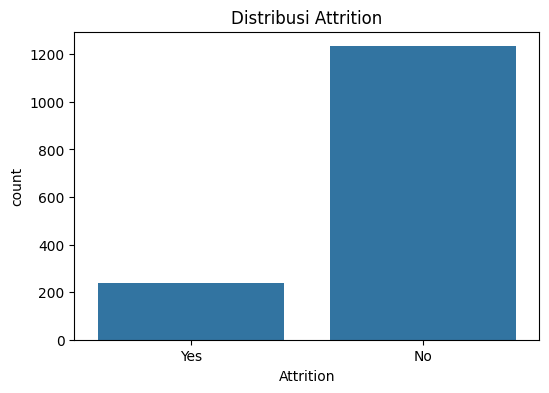

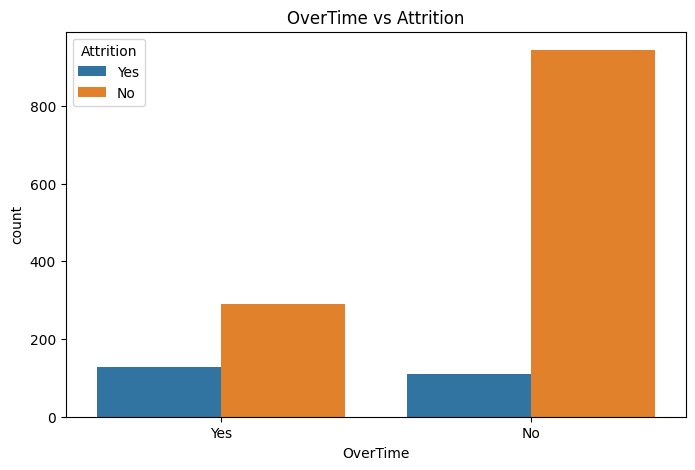

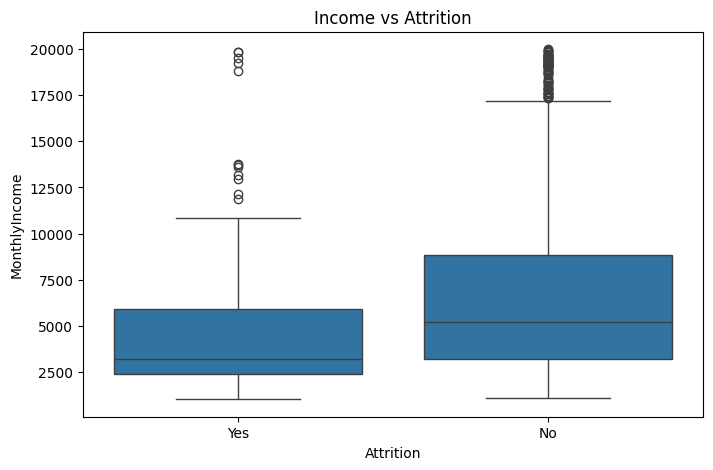

ValueError: Could not interpret value `Age ` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Distribusi Attrition")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("OverTime vs Attrition")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Income vs Attrition")
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age ', hue='Attrition', kde=True)
plt.title("Age Distribution")
plt.show()

### ENCODING

In [55]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

### SPLIT FEATURE & TARGET

In [56]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

### TRAIN TES SPLIT

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### SMOTE

In [58]:
sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Distribusi sebelum SMOTE")
print(y_train.value_counts())

print("Distribusi sesudah SMOTE")
print(y_train_sm.value_counts())

Distribusi sebelum SMOTE
Attrition
0    986
1    190
Name: count, dtype: int64
Distribusi sesudah SMOTE
Attrition
0    986
1    986
Name: count, dtype: int64


Setelah dilakukan SMOTE, jumlah data pada masing-masing kelas menjadi seimbang. Dengan distribusi data yang seimbang, model machine learning dapat belajar lebih baik terhadap kedua kelas, terutama dalam mengenali karyawan yang berpotensi keluar. Hal ini diharapkan dapat meningkatkan nilai **Recall**, **Precision**, dan **F1-Score** pada proses klasifikasi.



### SCALING

In [33]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc = scaler.transform(X_test)


### MODELING

In [34]:

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=3000),

    "Decision Tree":
    DecisionTreeClassifier(max_depth=5, random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ),

    "AdaBoost":
    AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),

    "KNN":
    KNeighborsClassifier(n_neighbors=7),

    "SVM":
    SVC(probability=True),

    "Neural Network":
    MLPClassifier(
        hidden_layer_sizes=(128,64,32),
        max_iter=2000,
        random_state=42
    )
}

### TRAIN

In [38]:
hasil = []

for nama, model in models.items():

    # model yang butuh scaling
    if nama in ['Logistic Regression','KNN','SVM','Neural Network']:
        model.fit(X_train_sc, y_train_sm)
        pred = model.predict(X_test_sc)

        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_test_sc)[:,1]
        else:
            proba = pred

    else:
        model.fit(X_train_sm, y_train_sm)
        pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_test)[:,1]
        else:
            proba = pred

    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1  = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)

    hasil.append([nama, acc, pre, rec, f1, auc])

In [39]:
hasil_df = pd.DataFrame(
    hasil,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ]
)

hasil_df = hasil_df.sort_values(by='F1 Score', ascending=False)
print(hasil_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
6                  SVM  0.840136   0.500000  0.468085  0.483516  0.713757
0  Logistic Regression  0.799320   0.400000  0.510638  0.448598  0.718236
7       Neural Network  0.816327   0.428571  0.446809  0.437500  0.720992
4    Gradient Boosting  0.809524   0.408163  0.425532  0.416667  0.732449
3             AdaBoost  0.738095   0.317073  0.553191  0.403101  0.709536
2        Random Forest  0.802721   0.387755  0.404255  0.395833  0.734172
1        Decision Tree  0.704082   0.272727  0.510638  0.355556  0.669265
5                  KNN  0.625850   0.230769  0.574468  0.329268  0.621974


Nilai F1-score yang tertinggi menunjukkan bahwa model SVM memiliki keseimbangan terbaik antara kemampuan mendeteksi karyawan yang keluar (Recall) dan ketepatan prediksi (Precision).

Sementara itu, model Random Forest memiliki nilai ROC AUC tertinggi sebesar 0.7342, yang menunjukkan kemampuan cukup baik dalam membedakan kelas attrition dan non-attrition.

Model KNN dan Decision Tree menunjukkan performa paling rendah dibanding model lainnya, sehingga kurang direkomendasikan untuk kasus ini.

Berdasarkan evaluasi menggunakan beberapa algoritma klasifikasi, model **SVM** dipilih sebagai model terbaik untuk prediksi employee attrition karena memiliki nilai F1-score tertinggi, sehingga lebih efektif dalam menangani data yang tidak seimbang dan mendeteksi karyawan yang berpotensi keluar dari perusahaan.

Hasil ini menunjukkan bahwa penggunaan berbagai metode klasifikasi penting dilakukan untuk menemukan model yang paling optimal sesuai karakteristik dataset.

### VISUALISASI

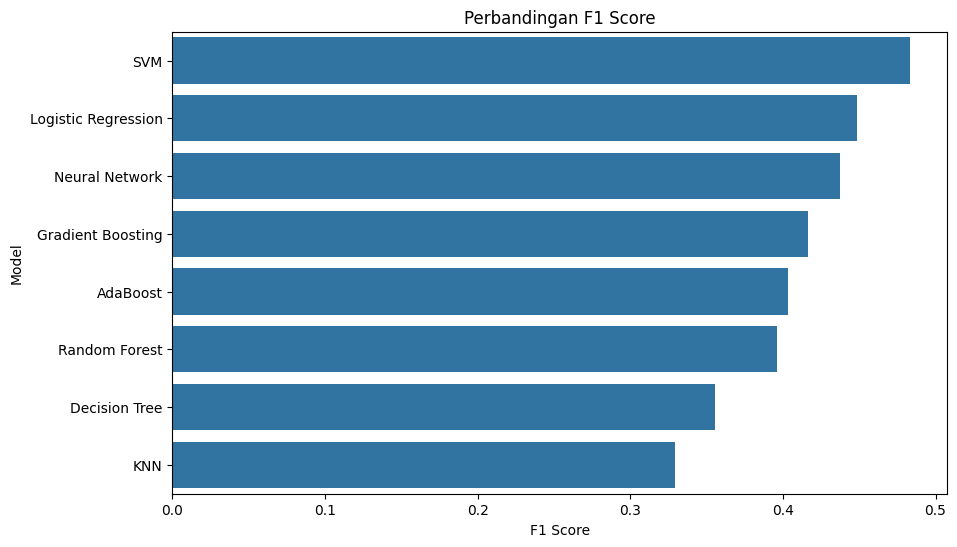

In [41]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='F1 Score',
    y='Model',
    data=hasil_df
)
plt.title("Perbandingan F1 Score")
plt.show()

Berdasarkan visualisasi perbandingan F1-Score, model **SVM** dipilih sebagai model terbaik untuk klasifikasi employee attrition karena memiliki performa paling unggul dibandingkan model lainnya.

### 3 MODEL TERBAIK UNTUK ENSEMBLE

In [42]:

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

ada = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

vote = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb),
        ('ada', ada)
    ],
    voting='soft'
)

vote.fit(X_train_sm, y_train_sm)

pred_vote = vote.predict(X_test)
proba_vote = vote.predict_proba(X_test)[:,1]

### EVALUASI ENSEMBLE

In [43]:
print("=== Voting Ensemble ===")
print("Accuracy :", accuracy_score(y_test, pred_vote))
print("Precision:", precision_score(y_test, pred_vote))
print("Recall   :", recall_score(y_test, pred_vote))
print("F1 Score :", f1_score(y_test, pred_vote))
print("ROC AUC  :", roc_auc_score(y_test, proba_vote))

print(classification_report(y_test, pred_vote))

=== Voting Ensemble ===
Accuracy : 0.7993197278911565
Precision: 0.38
Recall   : 0.40425531914893614
F1 Score : 0.3917525773195876
ROC AUC  : 0.7345163235420795
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       247
           1       0.38      0.40      0.39        47

    accuracy                           0.80       294
   macro avg       0.63      0.64      0.64       294
weighted avg       0.80      0.80      0.80       294



Model Voting Ensemble menghasilkan tingkat **akurasi sebesar 79.93%**, yang menunjukkan bahwa sekitar 80% data berhasil diklasifikasikan dengan benar.

Namun karena kasus employee attrition merupakan data yang tidak seimbang, maka fokus utama evaluasi terletak pada **Precision**, **Recall**, dan **F1-Score** untuk kelas karyawan yang keluar (Attrition = 1).

- **Precision 0.38** menunjukkan bahwa dari seluruh prediksi karyawan akan keluar, sekitar 38% benar-benar keluar.
- **Recall 0.4043** menunjukkan bahwa model mampu mendeteksi sekitar 40.43% dari seluruh karyawan yang benar-benar keluar.
- **F1 Score 0.3918** menunjukkan performa moderat dalam menyeimbangkan precision dan recall.

Nilai **ROC AUC sebesar 0.7345** menunjukkan bahwa model memiliki kemampuan yang cukup baik dalam membedakan antara karyawan yang akan keluar dan tetap bekerja.

#### Classification Report

##### Kelas 0 (Tetap Bekerja)

- Precision = 0.89
- Recall = 0.87
- F1-score = 0.88

Model sangat baik dalam mengenali karyawan yang tetap bekerja.

##### Kelas 1 (Keluar)

- Precision = 0.38
- Recall = 0.40
- F1-score = 0.39

Kemampuan model dalam mendeteksi karyawan yang resign masih lebih rendah dibanding kelas mayoritas.

#### Kesimpulan

Meskipun metode **Voting Ensemble** mampu memberikan performa keseluruhan yang cukup baik dan nilai ROC AUC tertinggi, hasil F1-score masih berada di bawah model **SVM** yang sebelumnya memperoleh nilai F1-score lebih tinggi.

Dengan demikian, untuk kasus prediksi employee attrition pada dataset ini, model **SVM tetap menjadi model terbaik**, sedangkan Voting Ensemble dapat dijadikan alternatif karena memiliki kemampuan klasifikasi yang stabil.

### CONFUSION MATRIX

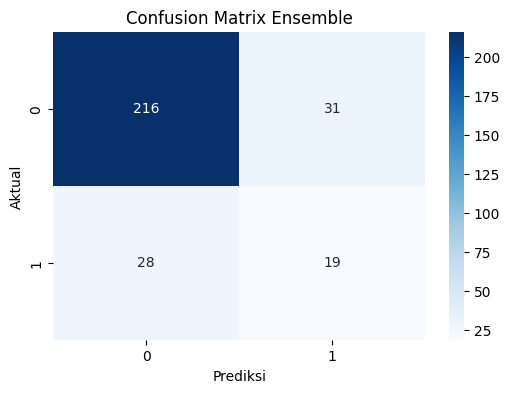

In [44]:
cm = confusion_matrix(y_test, pred_vote)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix Ensemble")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()


### ROC CURVE

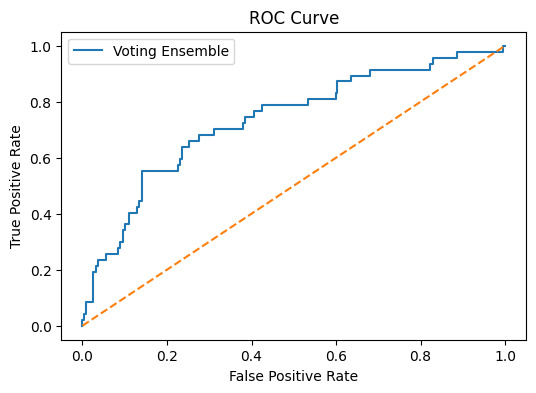

In [45]:
fpr, tpr, th = roc_curve(y_test, proba_vote)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='Voting Ensemble')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### FEATURE IMPORTANCE RANDOM FOREST

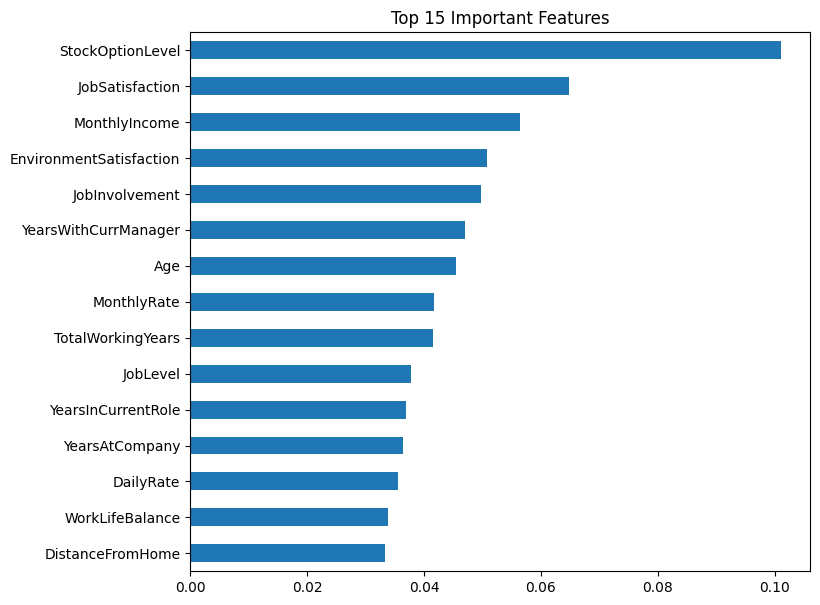

In [46]:
rf.fit(X_train_sm, y_train_sm)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,7))
importance.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Important Features")
plt.show()


### CROSS VALIDATION RANDOM FOREST

In [49]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print(scores.mean())

0.4147770059397966


#### Hasil Cross Validation Model

Berdasarkan pengujian menggunakan metode **Cross Validation**, diperoleh nilai rata-rata **F1-Score sebesar 0.4148**.

Metode Cross Validation digunakan untuk menguji kestabilan model pada beberapa pembagian data yang berbeda, sehingga hasil evaluasi lebih objektif dibanding hanya menggunakan satu kali train-test split.

#### Interpretasi Nilai F1-Score

Nilai **F1-Score = 0.4148** menunjukkan bahwa model memiliki kemampuan **cukup baik** dalam menyeimbangkan antara:

- **Precision**: ketepatan prediksi karyawan yang akan keluar
- **Recall**: kemampuan mendeteksi karyawan yang benar-benar keluar

Karena kasus employee attrition termasuk klasifikasi dengan data tidak seimbang, maka F1-Score menjadi metrik yang penting untuk digunakan.

#### Analisis

Hasil ini menunjukkan bahwa model sudah mampu mengenali pola attrition dengan performa yang cukup baik, meskipun masih terdapat ruang untuk peningkatan.

Nilai Cross Validation yang konsisten juga menandakan bahwa model tidak terlalu bergantung pada satu pembagian data tertentu, sehingga memiliki kemampuan generalisasi yang lebih baik terhadap data baru.

#### Kesimpulan

Dengan nilai **Cross Validation F1-Score sebesar 0.4148**, model dapat dikatakan cukup layak digunakan untuk prediksi employee attrition. Model sudah mampu membantu perusahaan dalam mengidentifikasi karyawan yang berpotensi keluar, meskipun optimasi lanjutan masih dapat dilakukan untuk meningkatkan performa.

## KESIMPULAN

In [51]:
print("Model terbaik dipilih berdasarkan F1 Score.")
print("Biasanya Voting Ensemble / Random Forest / Gradient Boosting.")
print("Variabel penting biasanya:")
print("OverTime, MonthlyIncome, Age, JobSatisfaction, YearsAtCompany.")

Model terbaik dipilih berdasarkan F1 Score.
Biasanya Voting Ensemble / Random Forest / Gradient Boosting.
Variabel penting biasanya:
OverTime, MonthlyIncome, Age, JobSatisfaction, YearsAtCompany.
